#  Análise de Vendas e Lucratividade

Este projeto tem como objetivo analisar dados de vendas para identificar fatores que impactam o lucro, com foco em descontos, categorias e comportamento ao longo do tempo.

**Importação de Bibliotecas**

Importação das bibliotecas necessárias para manipulação e visualização dos dados.

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [45]:
!conda install matplotlib -y

3 channel Terms of Service accepted
Channels:
 - defaults
Platform: win-64
Solving environment: done

# All requested packages already installed.





==> WARNING: A newer version of conda exists. <==
    current version: 25.11.1
    latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c defaults conda




**Carregamento de Dados**

Leitura do dataset e visualização inicial da estrutura dos dados.

In [30]:
df = pd.read_csv('D:\projeto-superstore\data\custom_superstore_dataset.csv')

In [31]:
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Segment,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,ORD-1000,2022-04-13,2022-04-16,Second Class,Corporate,Southeast,Furniture,Binders,156.01,8,0.1,45.71
1,ORD-1001,2022-12-15,2022-12-18,Second Class,Home Office,Midwest,Furniture,Tables,421.87,5,0.0,119.17
2,ORD-1002,2022-09-28,2022-09-29,Standard Class,Home Office,Midwest,Office Supplies,Binders,280.64,2,0.4,-17.52
3,ORD-1003,2022-04-17,2022-04-23,Same Day,Home Office,South,Technology,Paper,199.43,9,0.1,39.53
4,ORD-1004,2022-03-13,2022-03-15,First Class,Corporate,West,Office Supplies,Binders,320.16,3,0.0,103.76


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order ID      1000 non-null   object 
 1   Order Date    1000 non-null   object 
 2   Ship Date     1000 non-null   object 
 3   Ship Mode     1000 non-null   object 
 4   Segment       1000 non-null   object 
 5   Region        1000 non-null   object 
 6   Category      1000 non-null   object 
 7   Sub-Category  1000 non-null   object 
 8   Sales         1000 non-null   float64
 9   Quantity      1000 non-null   int64  
 10  Discount      1000 non-null   float64
 11  Profit        1000 non-null   float64
dtypes: float64(3), int64(1), object(8)
memory usage: 93.9+ KB


**Limpeza de Dados**

Padronização dos nomes das colunas para facilitar a manipulação e evitar inconsistências.

In [33]:
df.columns = df.columns.str.strip().str.lower()

In [34]:
df['order date']

0      2022-04-13
1      2022-12-15
2      2022-09-28
3      2022-04-17
4      2022-03-13
          ...    
995    2022-02-07
996    2022-10-20
997    2022-05-19
998    2022-12-22
999    2022-11-29
Name: order date, Length: 1000, dtype: object

**Transformação de Dados**

Conversão de tipos e criação de novas variáveis para análise temporal.

Conversão de Datas

In [36]:
df['order date'] = pd.to_datetime(df['order date'])
df['ship date'] = pd.to_datetime(df['ship date'])

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order id      1000 non-null   object        
 1   order date    1000 non-null   datetime64[ns]
 2   ship date     1000 non-null   datetime64[ns]
 3   ship mode     1000 non-null   object        
 4   segment       1000 non-null   object        
 5   region        1000 non-null   object        
 6   category      1000 non-null   object        
 7   sub-category  1000 non-null   object        
 8   sales         1000 non-null   float64       
 9   quantity      1000 non-null   int64         
 10  discount      1000 non-null   float64       
 11  profit        1000 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(1), object(6)
memory usage: 93.9+ KB


In [38]:
df['order date'] = pd.to_datetime(df['order date'])
df['ship date'] = pd.to_datetime(df['ship date'])

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order id      1000 non-null   object        
 1   order date    1000 non-null   datetime64[ns]
 2   ship date     1000 non-null   datetime64[ns]
 3   ship mode     1000 non-null   object        
 4   segment       1000 non-null   object        
 5   region        1000 non-null   object        
 6   category      1000 non-null   object        
 7   sub-category  1000 non-null   object        
 8   sales         1000 non-null   float64       
 9   quantity      1000 non-null   int64         
 10  discount      1000 non-null   float64       
 11  profit        1000 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(1), object(6)
memory usage: 93.9+ KB


Criação de Colunas

In [40]:
df['year'] = df['order date'].dt.year
df['month'] = df['order date'].dt.month
df['month_name'] = df['order date'].dt.month_name()

In [41]:
df['year_month'] = df['order date'].dt.to_period('M')

**Análise de Dados**

Exploração dos dados para identificar padrões e relações relevantes para o negócio.

In [42]:
df.groupby('year_month')['sales'].sum().sort_index()

year_month
2022-01    19162.75
2022-02    23316.42
2022-03    15449.14
2022-04    22527.55
2022-05    24230.86
2022-06    22545.13
2022-07    18825.43
2022-08    24218.06
2022-09    22896.71
2022-10    21478.09
2022-11    18859.92
2022-12    23077.30
Freq: M, Name: sales, dtype: float64

Qual mês vendeu mais?

Matplotlib is building the font cache; this may take a moment.


<Axes: xlabel='year_month'>

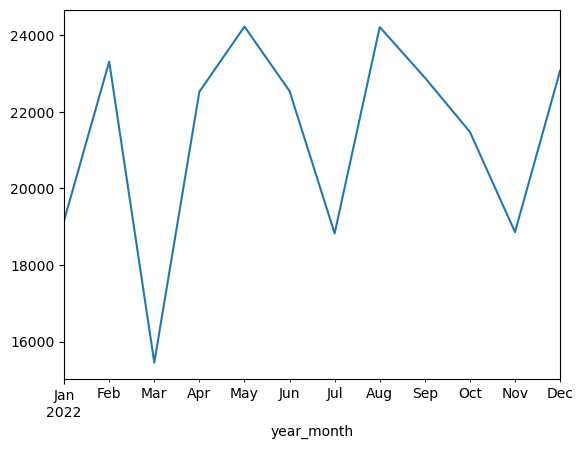

In [46]:
df.groupby('year_month')['sales'].sum().plot()

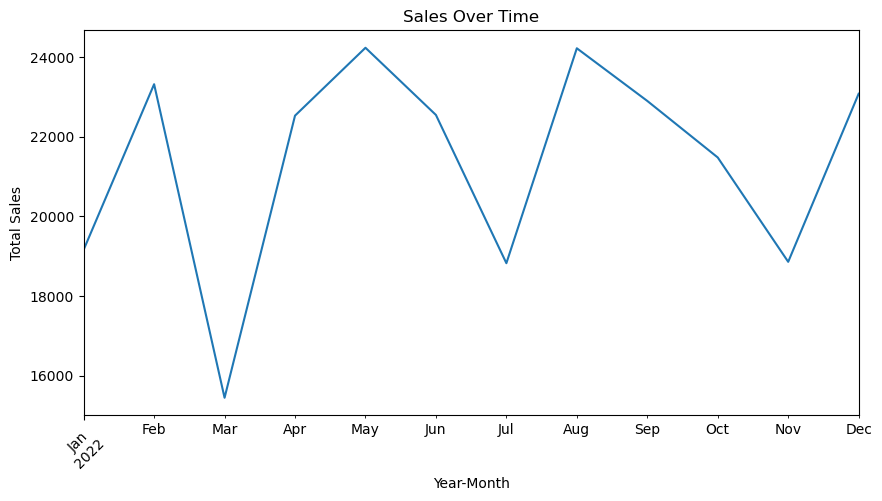

In [47]:
import matplotlib.pyplot as plt

sales_by_month = df.groupby('year_month')['sales'].sum()

sales_by_month.plot(figsize=(10,5))

plt.title('Sales Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.show()

Venda vs Lucro

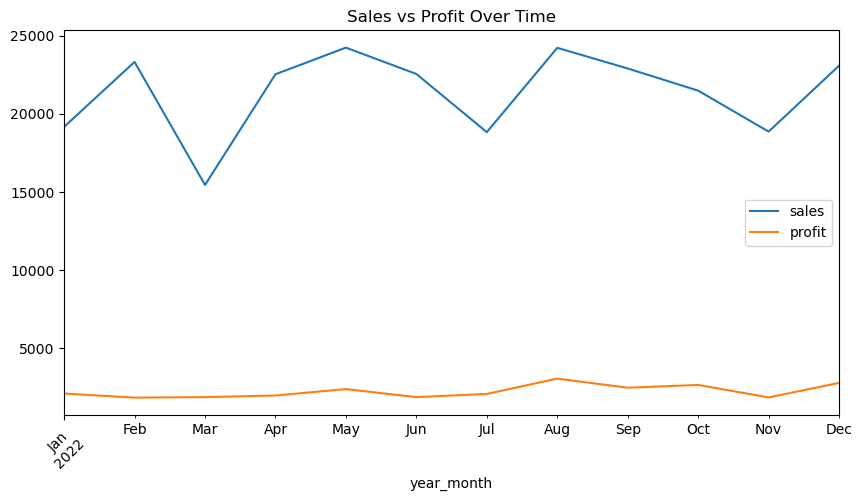

In [48]:
df.groupby('year_month')[['sales', 'profit']].sum().plot(figsize=(10,5))
plt.title('Sales vs Profit Over Time')
plt.xticks(rotation=45)
plt.show()

Impacto do desconto

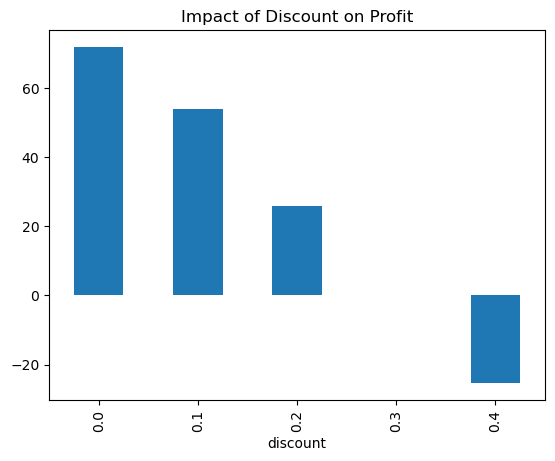

In [49]:
df.groupby('discount')['profit'].mean().plot(kind='bar')
plt.title('Impact of Discount on Profit')
plt.show()

Quem está dando prejuízo?

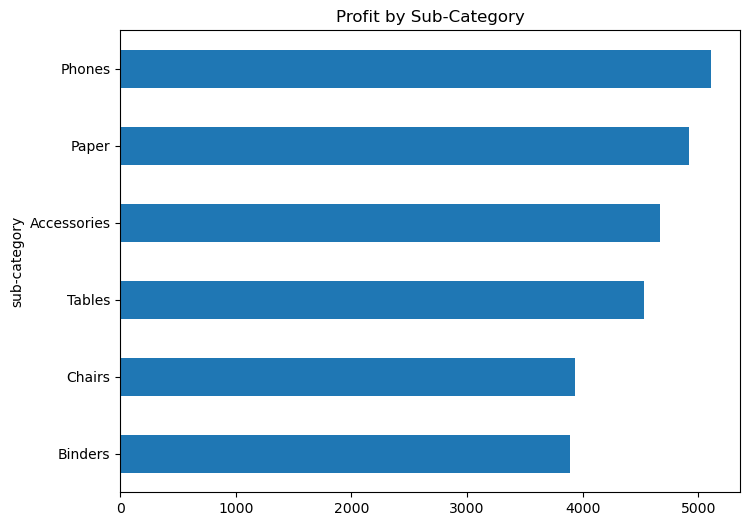

In [50]:
df.groupby('sub-category')['profit'].sum().sort_values().plot(kind='barh', figsize=(8,6))
plt.title('Profit by Sub-Category')
plt.show()

Performance por região

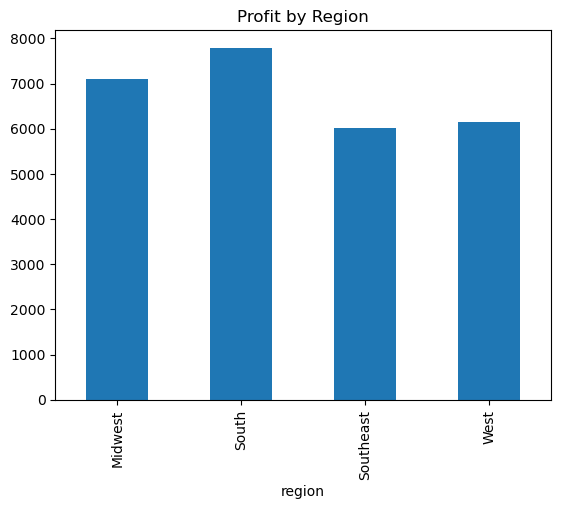

In [51]:
df.groupby('region')['profit'].sum().plot(kind='bar')
plt.title('Profit by Region')
plt.show()

Segmentos de cliente

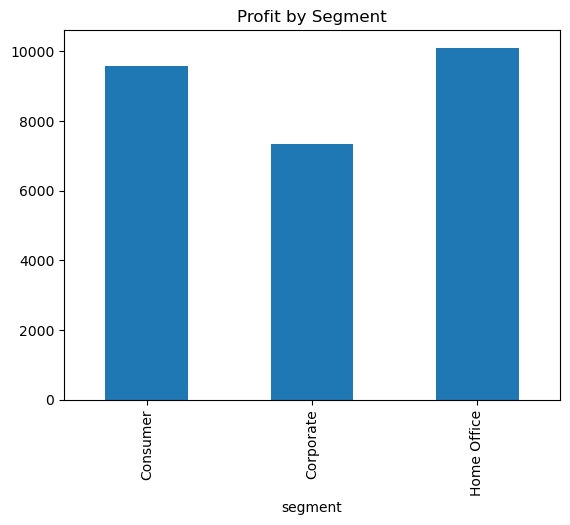

In [52]:
df.groupby('segment')['profit'].sum().plot(kind='bar')
plt.title('Profit by Segment')
plt.show()

Correlação 

In [53]:
df[['sales', 'profit', 'discount', 'quantity']].corr()

,sales,profit,discount,quantity
sales,1.000000,0.328614,0.010667,0.024208
profit,0.328614,1.000000,-0.794918,-0.023943
discount,0.010667,-0.794918,1.000000,0.026936
quantity,0.024208,-0.023943,0.026936,1.000000


**Visualização**

Construção de gráficos para facilitar a interpretação dos resultados.

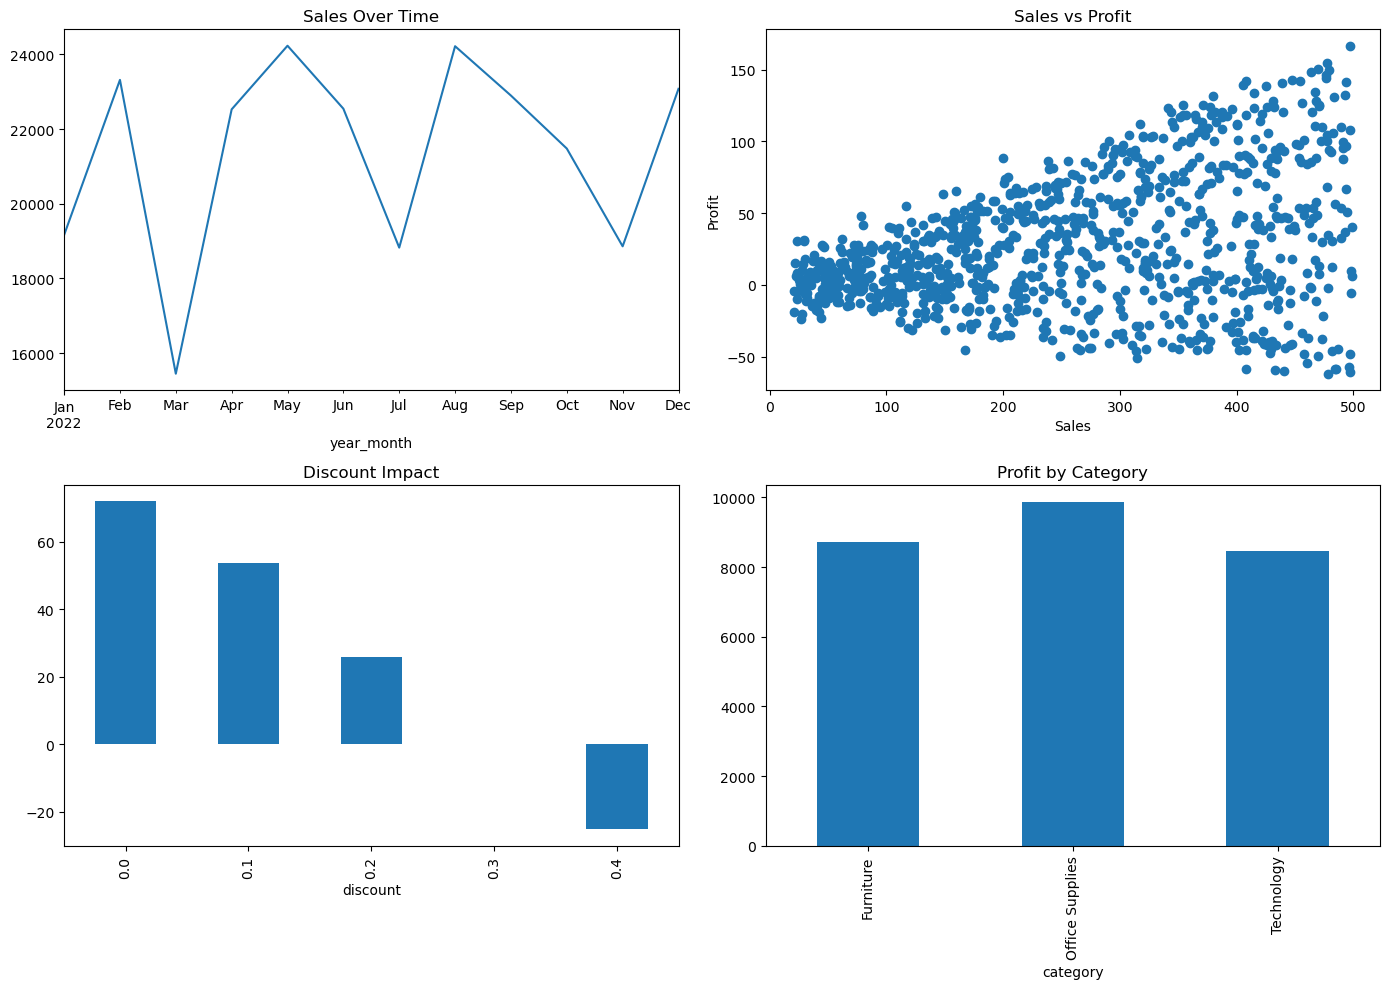

In [56]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14,10))

# 1. Vendas ao longo do tempo
df.groupby('year_month')['sales'].sum().plot(ax=axes[0,0], title='Sales Over Time')

# 2. Sales vs Profit
axes[0,1].scatter(df['sales'], df['profit'])
axes[0,1].set_title('Sales vs Profit')
axes[0,1].set_xlabel('Sales')
axes[0,1].set_ylabel('Profit')

# 3. Impacto do desconto
df.groupby('discount')['profit'].mean().plot(kind='bar', ax=axes[1,0], title='Discount Impact')

# 4. Categoria
df.groupby('category')['profit'].sum().plot(kind='bar', ax=axes[1,1], title='Profit by Category')

plt.tight_layout()
plt.show()